# Modelo de predicción de inscripciones estudiantiles mediante técnicas de Machine Learning

**Maestría en Inteligencia Artificial Aplicada**

**Proyecto Integrador Sep-Nov 2025**

**Equipo 14**

**Integrantes:**

- Alejandro Roa Solis – A01129942
- Annette Cristina Narvaez Andrade – A00571041
- Karla Alejandra Fonseca Márquez – A01795313


**Patrocinador Tec de Monterrey:**

Dr. Juan Arturo Nolazco Flores, Director del Hub de Ciencias y Datos de la Escuela de Ingeniería del Tec de Monterrey

In [1]:
# ===== 0) Paquetes =====
import os, json
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, MaxAbsScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import CountVectorizer, FeatureHasher
from sklearn.metrics import (classification_report, roc_auc_score,
                             RocCurveDisplay, PrecisionRecallDisplay,
                             confusion_matrix)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import joblib


In [10]:
# ===== 1) Parámetros =====
CSV_PATH    = "admited_prepa.csv"   # <--- pon aquí tu CSV
TARGET_COL  = "INSCRITO"        # target binario 0/1
RANDOM_SEED = 42
TEST_SIZE   = 0.2

# (opcional) si tienes el JSON de featurización exportado por AutoML:
AUTO_FEAT_JSON = "featurization.json"  # ajústalo si lo tienes local

df = pd.read_csv(CSV_PATH)

y = df[TARGET_COL].astype(int)
X = df.drop(columns=[TARGET_COL]).copy()



In [11]:
# ===== 3) Columnas por tipo (desde featurization_summary si está disponible) =====
chargram_cols = []        # CountVectorizer por columna
hash_ohe_cols = []        # hashing one-hot (1024)
labelenc_cols = []        # OrdinalEncoder
numeric_cols_no_marker = []
numeric_cols_with_marker = []
date_cols = []

if os.path.exists(AUTO_FEAT_JSON):
    with open(AUTO_FEAT_JSON, "r", encoding="utf-8") as f:
        feats = json.load(f)

    for item in feats:
        col = item["RawFeatureName"]
        if col not in X.columns: 
            continue
        t  = item.get("TypeDetected", "")
        trans = " ".join(item.get("Transformations", []))
        if "HashOneHotEncoder" in trans:
            hash_ohe_cols.append(col)
        elif "CountVectorizer" in trans:
            chargram_cols.append(col)
        elif "LabelEncoder" in trans:
            labelenc_cols.append(col)
        elif t == "Numeric":
            if "ImputationMarker" in trans:
                numeric_cols_with_marker.append(col)
            else:
                numeric_cols_no_marker.append(col)
        elif t == "DateTime":
            date_cols.append(col)

# En caso de que no exista el JSON, puedes rellenar manualmente las listas de arriba.

def keep_existing(cols): 
    return [c for c in cols if c in X.columns]

chargram_cols = keep_existing(chargram_cols)
hash_ohe_cols = keep_existing(hash_ohe_cols)
labelenc_cols = keep_existing(labelenc_cols)
numeric_cols_no_marker = keep_existing(numeric_cols_no_marker)
numeric_cols_with_marker = keep_existing(numeric_cols_with_marker)
date_cols = keep_existing(date_cols)

print("CV:", len(chargram_cols), "HASH:", len(hash_ohe_cols), 
      "LabelEnc:", len(labelenc_cols), "Num:", len(numeric_cols_no_marker),
      "Num+marker:", len(numeric_cols_with_marker), "Fechas:", len(date_cols))


CV: 9 HASH: 1 LabelEnc: 2 Num: 12 Num+marker: 4 Fechas: 1


In [12]:
# ===== 4) Transformadores custom =====
class SingleColumnVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, column, **cv_kwargs):
        self.column = column
        self.cv_kwargs = cv_kwargs
        self.vec = CountVectorizer(**cv_kwargs)
    def fit(self, X, y=None):
        col = pd.Series(X[self.column]).astype(str).fillna("")
        self.vec.fit(col)
        return self
    def transform(self, X):
        col = pd.Series(X[self.column]).astype(str).fillna("")
        return self.vec.transform(col)

class SingleColumnHasher(BaseEstimator, TransformerMixin):
    def __init__(self, column, n_features=1024):
        self.column = column
        self.n_features = n_features
        self.hasher = FeatureHasher(n_features=n_features, input_type="string")
    def fit(self, X, y=None): 
        return self
    def transform(self, X):
        col = pd.Series(X[self.column]).astype(str).fillna("")
        return self.hasher.transform([[v] for v in col.values])

class DateTimeFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        feats = []
        for c in self.columns:
            s = pd.to_datetime(X[c], errors="coerce")
            dfp = pd.DataFrame({
                f"{c}__year": s.dt.year,
                f"{c}__month": s.dt.month,
                f"{c}__day": s.dt.day,
                f"{c}__dayofweek": s.dt.dayofweek,
                f"{c}__quarter": s.dt.quarter,
                f"{c}__dayofyear": s.dt.dayofyear,
                f"{c}__is_month_start": s.dt.is_month_start.astype(float),
                f"{c}__is_month_end": s.dt.is_month_end.astype(float),
                f"{c}__is_quarter_start": s.dt.is_quarter_start.astype(float),
                f"{c}__is_quarter_end": s.dt.is_quarter_end.astype(float),
            })
            feats.append(dfp)
        return pd.concat(feats, axis=1).fillna(0).values


In [18]:
# ===== REDEFINIR EL COLUMNTRANSFORMER CON NOMBRES "SEGUROS" =====
num_no_marker = make_pipeline(SimpleImputer(strategy="mean"))
num_with_marker = make_pipeline(SimpleImputer(strategy="mean", add_indicator=True))

label_enc = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
)

def safe_name(prefix, col):
    # sin dobles guiones bajos ni espacios
    return f"{prefix}_{col}".replace("__", "_").replace(" ", "_")

cv_transformers = []
for c in chargram_cols:
    cv_transformers.append((
        safe_name("cv", c),
        SingleColumnVectorizer(
            column=c, analyzer="word", binary=True, lowercase=True,
            token_pattern=r"(?u)\b\w\w+\b", min_df=1, max_df=1.0
        ),
        [c]
    ))

hash_transformers = []
for c in hash_ohe_cols:
    hash_transformers.append((
        safe_name("hash", c),
        SingleColumnHasher(column=c, n_features=1024),
        [c]
    ))

dt_transformer = ("dates", DateTimeFeatures(columns=date_cols), date_cols) if date_cols else None

transformers = []
if numeric_cols_no_marker:   transformers.append(("num", num_no_marker, numeric_cols_no_marker))
if numeric_cols_with_marker: transformers.append(("num_miss", num_with_marker, numeric_cols_with_marker))
if labelenc_cols:            transformers.append(("label", label_enc, labelenc_cols))
if dt_transformer:           transformers.append(dt_transformer)
transformers += cv_transformers + hash_transformers

preprocess = ColumnTransformer(transformers=transformers, remainder="drop", sparse_threshold=0.3)

normalizer = MaxAbsScaler()


In [19]:
# ===== 6) Train/test split =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

# (opcional) compensar desbalance con scale_pos_weight
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0
scale_pos_weight


np.float64(0.2244474113632992)

In [20]:
# ===== 7) Modelo XGBoost (hiperparámetros del AutoML) =====
xgb = XGBClassifier(
    booster="gbtree",
    learning_rate=0.1,           # eta
    colsample_bytree=0.8,
    gamma=10,
    max_depth=6,
    n_estimators=100,
    subsample=0.7,
    reg_lambda=0.8333333333333334,
    reg_alpha=0.0,
    objective="binary:logistic",
    tree_method="auto",
    n_jobs=-1,
    random_state=RANDOM_SEED,
    eval_metric="logloss",
    # descomenta si quieres usarlo:
    # scale_pos_weight=scale_pos_weight
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("normalize",  normalizer),
    ("clf",        xgb)
])

model.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('normalize', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('num_miss', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


              precision    recall  f1-score   support

           0     0.8714    0.1614    0.2723       378
           1     0.8410    0.9947    0.9114      1686

    accuracy                         0.8421      2064
   macro avg     0.8562    0.5780    0.5919      2064
weighted avg     0.8466    0.8421    0.7944      2064

ROC AUC: 0.788814827367615
Matriz de confusión:
 [[  61  317]
 [   9 1677]]


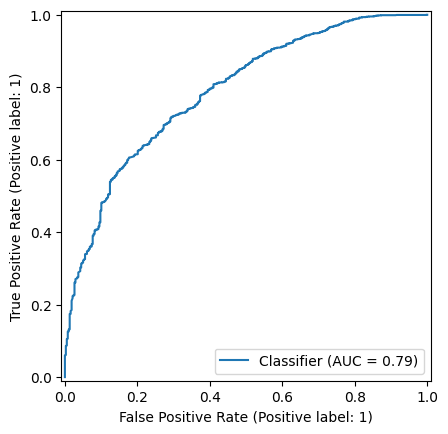

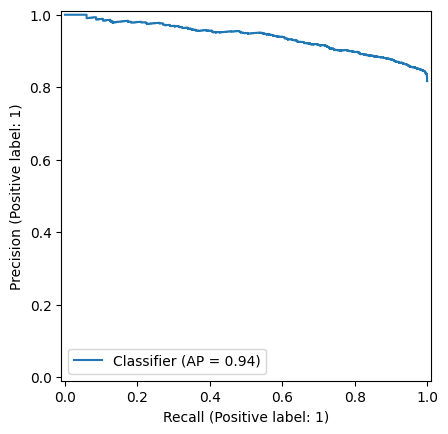

In [21]:
# ===== 8) Evaluación =====
pred_proba = model.predict_proba(X_test)[:,1]
pred = (pred_proba >= 0.5).astype(int)

print(classification_report(y_test, pred, digits=4))
print("ROC AUC:", roc_auc_score(y_test, pred_proba))
print("Matriz de confusión:\n", confusion_matrix(y_test, pred))

_ = RocCurveDisplay.from_predictions(y_test, pred_proba)
_ = PrecisionRecallDisplay.from_predictions(y_test, pred_proba)
